In [1]:
%%capture
!pip install indiafactorlibrary

In [2]:
# Notebook: 03_intro_to_ap
# Series:   pyIndiaFactorInvesting
# Data:     Invespar Indian Factor Library + Nifty sample + Fund sample
# Run in:   Colab / Binder / local
# Author:   Rajan Raju

# Introduction to Asset Pricing Models

A fund returned 18% last year. Is that good? It depends on what risks it took. Asset pricing models provide a systematic framework for answering this question — they decompose a return stream into compensation for risk exposures and a residual that may (or may not) reflect genuine skill. This notebook builds the intuition, the mechanics, and the practical awareness needed to use these models on Indian data.

**What you will leave with**
- The difference between holdings-based and return-based analysis
- A visual feel for how risk and return relate across factors, style indices, and funds
- The regression mechanics behind CAPM and multi-factor models
- An understanding of what α, β, R², and t-statistics mean in practice
- Awareness of where financial data breaks standard regression assumptions

**Prerequisites:** Notebooks 00–02 (familiarity with Indian factor data and construction)

In [3]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from statsmodels.stats.outliers_influence import variance_inflation_factor

sys.path.insert(0, str(Path('.').resolve().parent))

import indiafactorlibrary as ifl
from src.data import load_nifty_sample, load_fund_sample

# IndiaFactorLibrary client with browser User-Agent (required)
_lib = ifl.IndiaFactorLibrary()
_lib.session.headers.update({
    'User-Agent': (
        'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    )
})

def read(name):
    return _lib.read(name)

In [4]:
# ── Factor data ──────────────────────────────────────────────────────────────
ff6_raw = read('FF6')[0]
ff6_raw.index = pd.to_datetime(ff6_raw.index)
ff6 = ff6_raw / 100   # percent → decimal

# ── Nifty style indices ──────────────────────────────────────────────────────
nifty_raw = load_nifty_sample()   # already decimal, 2015-01 to 2020-12

# ── Fund sample ──────────────────────────────────────────────────────────────
funds_raw = load_fund_sample()    # already decimal

print("FF6 columns    :", ff6.columns.tolist())
print("FF6 period     :", ff6.index.min().strftime('%b %Y'), '–', ff6.index.max().strftime('%b %Y'))
print("Nifty columns  :", nifty_raw.columns.tolist())
print("Nifty period   :", nifty_raw.index.min().strftime('%b %Y'), '–', nifty_raw.index.max().strftime('%b %Y'))
print("Fund columns   :", funds_raw.columns.tolist())
print("Fund period    :", funds_raw.index.min().strftime('%b %Y'), '–', funds_raw.index.max().strftime('%b %Y'))

FF6 columns    : ['MF', 'SMB5', 'HML', 'RMW', 'CMA', 'WML', 'RF', 'MKT']
FF6 period     : Oct 2004 – Feb 2026
Nifty columns  : ['nifty100', 'nifty_midcap150', 'nifty_smallcap250', 'nifty500_value50', 'nifty100_quality30', 'nifty_midcap150_quality50', 'nifty_smallcap250_quality50', 'nifty200_momentum30', 'nifty_midcap150_momentum50']
Nifty period   : Jan 2015 – Dec 2020
Fund columns   : ['Fund_A', 'Fund_B', 'Fund_C']
Fund period    : Jan 2015 – Dec 2020


## 1  The Problem: What Drives Returns?

Two approaches exist for understanding what drives a fund's returns.

**Holdings-based analysis** examines what a fund owns, how weights change, and what trades are made. It is powerful when done well — you can see selection, allocation, and timing directly. But it requires complete holdings data (often unavailable or delayed), domain expertise to interpret sector and stock choices, and the analytical capacity to process thousands of positions over time. For most practitioners, this is impractical at scale.

**Return-based analysis** uses only the return stream — a single time series of monthly numbers. By regressing this series against known risk factors, we can decompose the return into systematic exposures (market, size, value, momentum, etc.) and a residual. The residual, if statistically significant, is what practitioners call alpha. This approach is accessible, scalable, and requires no holdings data. The tradeoff is that it tells you *what* exposures a fund has, not *why* the manager chose them.

This notebook focuses on return-based analysis using asset pricing models (APMs).

## 2  Risk and Return: The Basic Tradeoff

Markowitz (1952) formalised the intuition that investors face a tradeoff: higher expected returns require bearing higher risk. Risk, measured as the volatility of returns, can be reduced through diversification — but only the idiosyncratic component. Systematic risk (exposure to broad market movements, economic cycles, etc.) cannot be diversified away, and investors should be compensated for bearing it. The risk-free rate — approximated by short-term government securities — provides the baseline: any investment should offer a return above the risk-free rate to justify the risk taken.

But how do risk and return actually relate in Indian data? The scatter plot below maps annualised return against annualised volatility for three groups: Fama-French factors, Nifty style indices, and sample funds.

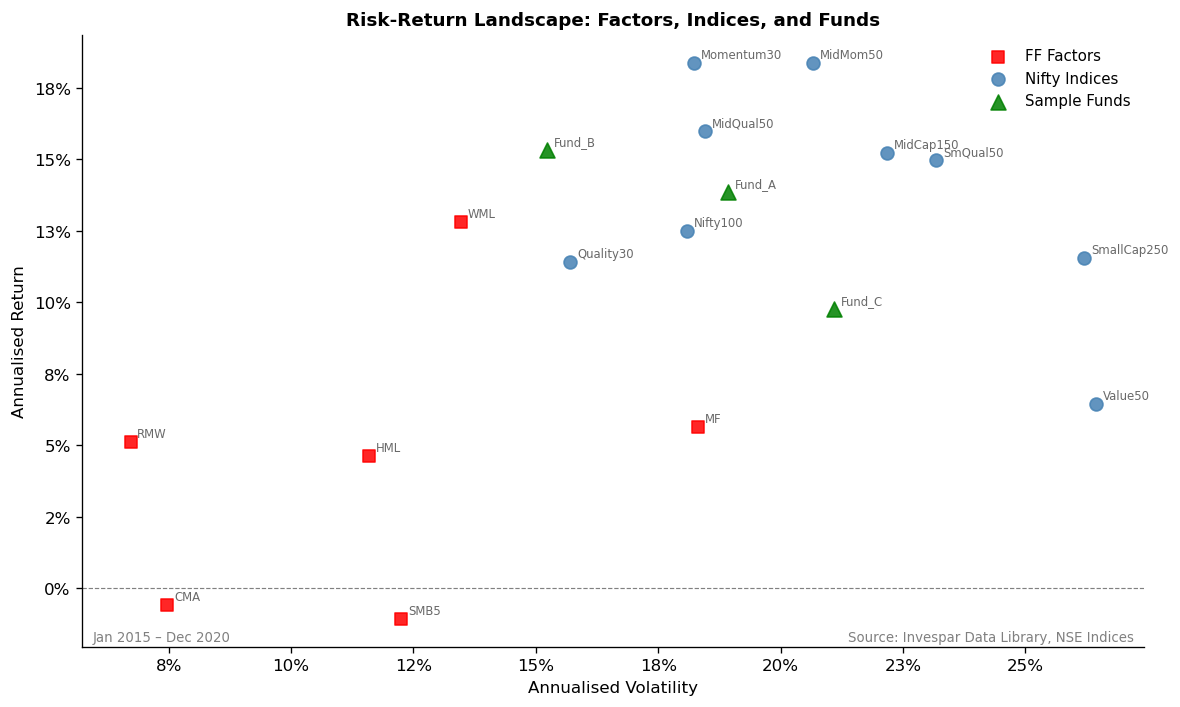

In [5]:
# ── Align all series to a common period ──────────────────────────────────────
common_start = max(ff6.index.min(), nifty_raw.index.min(), funds_raw.index.min())
common_end   = min(ff6.index.max(), nifty_raw.index.max(), funds_raw.index.max())

ff6_c    = ff6.loc[common_start:common_end]
nifty_c  = nifty_raw.loc[common_start:common_end]
funds_c  = funds_raw.loc[common_start:common_end]

# ── Compute annualised statistics ────────────────────────────────────────────
def ann_stats(series):
    ann_ret = (1 + series.mean()) ** 12 - 1
    ann_vol = series.std() * np.sqrt(12)
    return ann_ret, ann_vol

factor_cols  = ['MF', 'SMB5', 'HML', 'RMW', 'CMA', 'WML']
nifty_cols   = nifty_c.columns.tolist()
fund_cols    = funds_c.columns.tolist()

nifty_short = {
    'nifty100': 'Nifty100', 'nifty_midcap150': 'MidCap150',
    'nifty_smallcap250': 'SmallCap250', 'nifty500_value50': 'Value50',
    'nifty100_quality30': 'Quality30', 'nifty200_momentum30': 'Momentum30',
    'nifty_midcap150_quality50': 'MidQual50',
    'nifty_smallcap250_quality50': 'SmQual50',
    'nifty_midcap150_momentum50': 'MidMom50',
}

groups = [
    (ff6_c[factor_cols],        factor_cols,                 'FF Factors',     'red',   's', 60),
    (nifty_c,                   nifty_cols,                  'Nifty Indices',  'steelblue', 'o', 60),
    (funds_c,                   fund_cols,                   'Sample Funds',   'green', '^', 80),
]

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

for df, cols, label, color, marker, size in groups:
    first = True
    for col in cols:
        ret, vol = ann_stats(df[col].dropna())
        disp = nifty_short.get(col, col)
        ax.scatter(vol, ret, color=color, marker=marker, s=size,
                   label=label if first else '', zorder=3, alpha=0.85)
        ax.annotate(disp, (vol, ret), textcoords='offset points',
                    xytext=(4, 3), fontsize=7, color='dimgrey')
        first = False

ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
ax.set_xlabel('Annualised Volatility', fontsize=10)
ax.set_ylabel('Annualised Return', fontsize=10)
ax.set_title('Risk-Return Landscape: Factors, Indices, and Funds',
             fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)

period_str = f"{common_start.strftime('%b %Y')} – {common_end.strftime('%b %Y')}"
ax.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey')
ax.annotate('Source: Invespar Data Library, NSE Indices',
            xy=(0.99, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey', ha='right')

plt.tight_layout()
plt.show()

**Observations — Risk-Return Landscape**

The Nifty style indices cluster tightly — high return, high volatility, all in the same quadrant. They look different on paper (value, momentum, quality) but share so much market exposure that their risk-return profiles converge. The factors spread across the chart, including into negative-return territory — not all factors deliver positive premia over every period. The funds scatter between the two groups.

This chart is informative but incomplete: it cannot tell us whether a fund's return reflects skill or simply higher risk exposure. That is what asset pricing models are designed to answer.

## 3  Asset Pricing Models: The Framework

An asset pricing model expresses expected excess return as a linear combination of risk factor exposures:

> **r − r_f = α + β₁F₁ + β₂F₂ + ... + βₙFₙ + ε**

Where:
- **r** is the asset return; **r_f** is the risk-free rate; **r − r_f** is the *excess* return
- **F₁...Fₙ** are factor returns (e.g., MF, SMB5, HML) where MF = MKT − RF is the market excess return
- **β₁...βₙ** measure the asset's sensitivity to each factor
- **α** (alpha) is the return unexplained by factor exposures
- **ε** is the error term — noise that neither factors nor alpha explain

Three key assumptions underpin this framework:

1. **Linearity** — the relationship between factor exposures and returns is linear
2. **Information** — factor returns reflect commonly available information, not private signals
3. **Efficiency** — over time, prices reflect available information, so persistent unexplained returns (α) are unusual

The linearity assumption is what allows us to use ordinary least squares (OLS) regression — a simple, interpretable, and well-understood statistical tool.

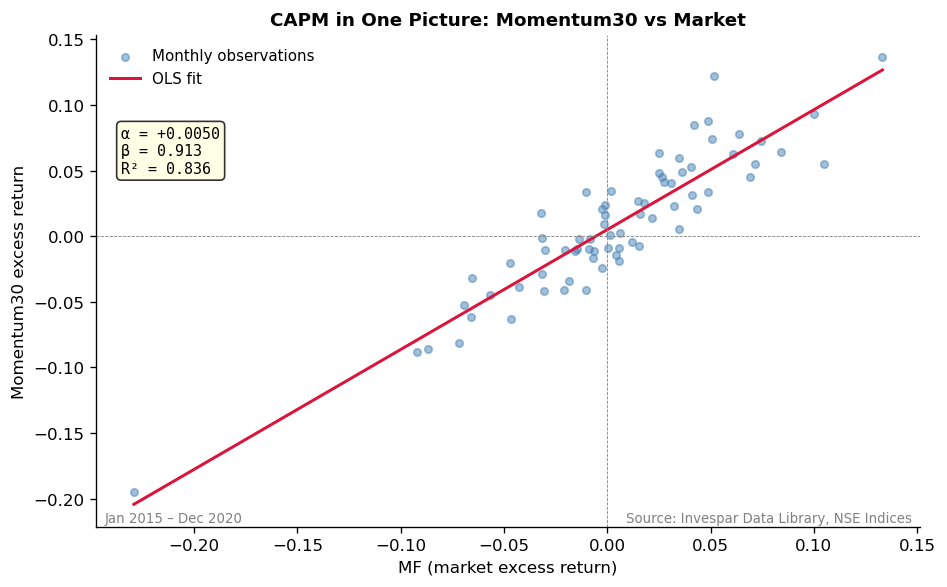

In [6]:
# ── Align Momentum30 and MF to common period ─────────────────────────────────
mom30 = nifty_raw['nifty200_momentum30'].rename('Momentum30')
mf    = ff6['MF']   # MF = MKT − RF (market excess return)
rf    = ff6['RF']

idx = mom30.index.intersection(mf.index)
mom30_xs = (mom30.loc[idx] - rf.loc[idx]).rename('Momentum30_xs')
mf_aligned = mf.loc[idx]

# ── OLS fit ──────────────────────────────────────────────────────────────────
capm_data = pd.DataFrame({'y': mom30_xs, 'x': mf_aligned}).dropna()
model = smf.ols('y ~ x', data=capm_data).fit()
alpha_val = model.params['Intercept']
beta_val  = model.params['x']
r2_val    = model.rsquared

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
ax.scatter(capm_data['x'], capm_data['y'], alpha=0.5, s=20,
           color='steelblue', label='Monthly observations')

x_line = np.linspace(capm_data['x'].min(), capm_data['x'].max(), 200)
ax.plot(x_line, model.params['Intercept'] + model.params['x'] * x_line,
        color='crimson', linewidth=1.8, label='OLS fit')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

ax.annotate(f'α = {alpha_val:+.4f}\nβ = {beta_val:.3f}\nR² = {r2_val:.3f}',
            xy=(0.03, 0.72), xycoords='axes fraction',
            fontsize=9, family='monospace',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax.set_xlabel('MF (market excess return)', fontsize=10)
ax.set_ylabel('Momentum30 excess return', fontsize=10)
ax.set_title('CAPM in One Picture: Momentum30 vs Market', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)

period_str = f"{idx.min().strftime('%b %Y')} – {idx.max().strftime('%b %Y')}"
ax.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey')
ax.annotate('Source: Invespar Data Library, NSE Indices',
            xy=(0.99, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey', ha='right')

plt.tight_layout()
plt.show()

**Reading the CAPM chart**

The slope of the line is **β** — how much Momentum30 moves for each unit move in the market. A β above 1 means the index amplifies market swings; below 1 means it dampens them.

The intercept is **α** — the return per month that the market alone cannot explain. Positive α suggests outperformance relative to market risk; negative α suggests underperformance.

The scatter around the line is **ε** — what neither the market nor alpha can account for, month by month.

This single picture is the CAPM. The question is: can we do better by adding more factors?

## 4  Regression Mechanics

OLS finds the line (or hyperplane) that minimises the sum of squared residuals. In finance, each regression coefficient has a specific interpretation.

**α (intercept):** excess return after controlling for factor exposures. If statistically significant and positive, the asset outperforms its risk profile. If statistically indistinguishable from zero, the model fully explains the returns.

**β (slope):** sensitivity to a factor. β = 1.0 on MF means the asset moves one-for-one with the market excess return. β = 0.3 on WML means it captures roughly 30% of the momentum premium per unit of momentum factor return.

**R²:** proportion of return variance explained by the model. A higher R² means the model leaves less unexplained. But a high R² does not mean the model is correct — it means it fits. A model with the wrong factors can still produce a high R² if those factors happen to be correlated with the true drivers.

**t-statistic:** measures whether a coefficient is statistically distinguishable from zero. In standard statistics, |t| > 2 (p < 0.05) is the threshold. In factor research, Harvey, Liu & Zhu (2016) argue that a higher bar — |t| > 3 — is more appropriate, given how many hypotheses are tested in empirical finance.

In [7]:
# ── Run CAPM: Momentum30 excess return ~ MF (market excess return) ───────────
capm_result = smf.ols('y ~ x', data=capm_data).fit(
    cov_type='HAC', cov_kwds={'maxlags': 3}
)
print(capm_result.summary())
print(f"\nPeriod: {idx.min().strftime('%b %Y')} – {idx.max().strftime('%b %Y')}  ({len(capm_data)} months)")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     449.7
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           3.43e-32
Time:                        10:38:22   Log-Likelihood:                 175.28
No. Observations:                  72   AIC:                            -346.6
Df Residuals:                      70   BIC:                            -342.0
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0050      0.002      2.223      0.0

**Reading the regression output**

Focus on four rows: `const` (α), `x` (β on MF), `R-squared`, and the t-statistics (column `t`).

- **`const` coefficient:** this is α — the monthly return unexplained by market exposure. Check the t-statistic: if |t| < 2, the alpha is not statistically distinguishable from zero at the 5% level. If |t| > 3, it passes the more conservative bar recommended for factor research.
- **`x` coefficient:** this is β on MF (market excess return). Read it as "for every 1% the market excess return moves, Momentum30 excess return moves approximately β%."
- **`R-squared`:** how much of the monthly variance in Momentum30 returns does the market alone explain? The remainder is explained by the factors we have not yet included.
- **Standard errors are HAC (Newey-West):** corrected for heteroscedasticity and autocorrelation — both of which are common in monthly return data (see Section 6).

Anything not covered by `const + β×MF` ends up in the residuals. The next step is to add more factors and watch what happens to α.

## 5  From CAPM to Multi-Factor Models

CAPM assumes the market is the only systematic risk factor. But the Indian equity market shows patterns the market alone cannot explain: small caps behave differently from large caps, momentum strategies deliver returns that persist after controlling for market risk, and quality firms diverge during stress periods. These anomalies motivated multi-factor models.

The models nest inside each other:

| Model | Formula |
|-------|---------|
| CAPM | r − r_f = α + β_M × MF + ε |
| Fama-French 3 (FF3) | + β_S × SMB + β_H × HML |
| Carhart FF4 | + β_W × WML |
| Fama-French 5 (FF5) | replaces SMB with SMB5, adds RMW and CMA |
| Fama-French 6 (FF6) | FF5 + WML — the full model used in this series |

MF = MKT − RF is the market excess return; it appears on the RHS because the dependent variable is also an excess return.

Each additional factor should reduce α if the asset's returns are driven by that factor exposure. If α persists after adding all six factors, something remains unexplained — possibly skill, possibly an omitted risk factor.

In [8]:
# ── Build regression dataset ─────────────────────────────────────────────────
# Align Momentum30, ff6 factors, RF to common index
idx_all = mom30.index.intersection(ff6.index)
reg = pd.DataFrame({
    'Mom30_xs': mom30.loc[idx_all] - ff6.loc[idx_all, 'RF'],
    'MF':    ff6.loc[idx_all, 'MF'],    # market excess return (MKT − RF)
    'SMB5':  ff6.loc[idx_all, 'SMB5'],
    'HML':   ff6.loc[idx_all, 'HML'],
    'RMW':   ff6.loc[idx_all, 'RMW'],
    'CMA':   ff6.loc[idx_all, 'CMA'],
    'WML':   ff6.loc[idx_all, 'WML'],
}).dropna()

hac_kwds = {'cov_type': 'HAC', 'cov_kwds': {'maxlags': 3}}

capm_m = smf.ols('Mom30_xs ~ MF',                           data=reg).fit(**hac_kwds)
ff4_m  = smf.ols('Mom30_xs ~ MF + SMB5 + HML + WML',       data=reg).fit(**hac_kwds)
ff6_m  = smf.ols('Mom30_xs ~ MF + SMB5 + HML + RMW + CMA + WML', data=reg).fit(**hac_kwds)

table = summary_col(
    [capm_m, ff4_m, ff6_m],
    model_names=['CAPM', 'FF4', 'FF6'],
    stars=True,
    info_dict={'R²': lambda m: f"{m.rsquared:.3f}",
               'Obs': lambda m: f"{int(m.nobs)}"},
)
print(table)
print(f"\nPeriod: {reg.index.min().strftime('%b %Y')} – {reg.index.max().strftime('%b %Y')}  ({len(reg)} months)")
print("Standard errors: HAC (Newey-West, maxlags=3)")


                  CAPM      FF4       FF6   
--------------------------------------------
CMA                                0.0527   
                                   (0.0972) 
HML                      0.0187    0.0796   
                         (0.0723)  (0.0846) 
Intercept      0.0050**  0.0008    -0.0001  
               (0.0022)  (0.0017)  (0.0019) 
MF             0.9134*** 1.0043*** 1.0152***
               (0.0431)  (0.0420)  (0.0497) 
R-squared      0.8363    0.9019    0.9041   
R-squared Adj. 0.8340    0.8960    0.8952   
RMW                                0.1773   
                                   (0.1382) 
SMB5                     -0.0420   -0.0558  
                         (0.0649)  (0.0609) 
WML                      0.3637*** 0.3572***
                         (0.0762)  (0.0756) 
R²             0.836     0.902     0.904    
Obs            72        72        72       
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01

Period: Jan 2015 – Dec 2020  (72 months

**What happens to α as we add factors**

Watch the `Intercept` row across the three columns. Under CAPM, Momentum30 may show a notable positive intercept — it appears to outperform. Once WML is added in FF4, the intercept typically shrinks. The "alpha" was largely momentum factor exposure all along. This is the core insight of factor models: what looks like skill may be systematic risk exposure that investors are being compensated for bearing.

The WML coefficient tells you directly how much of Momentum30's return is explained by the momentum factor. A high, significant WML coefficient confirms that the Nifty200 Momentum 30 index is, as expected, a momentum-tilted portfolio.

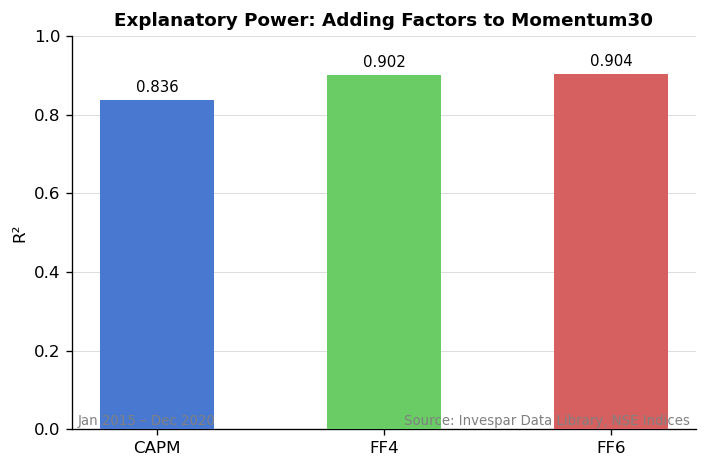

In [9]:
models      = [capm_m, ff4_m, ff6_m]
model_names = ['CAPM', 'FF4', 'FF6']
r2_vals     = [m.rsquared for m in models]

fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
bars = ax.bar(model_names, r2_vals, color=['#4878cf', '#6acc65', '#d65f5f'],
              width=0.5, zorder=3)
ax.bar_label(bars, labels=[f'{v:.3f}' for v in r2_vals],
             padding=3, fontsize=9)

ax.set_ylim(0, 1.0)
ax.set_ylabel('R²', fontsize=10)
ax.set_title('Explanatory Power: Adding Factors to Momentum30',
             fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)

period_str = f"{reg.index.min().strftime('%b %Y')} – {reg.index.max().strftime('%b %Y')}"
ax.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey')
ax.annotate('Source: Invespar Data Library, NSE Indices',
            xy=(0.99, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey', ha='right')

plt.tight_layout()
plt.show()

**R² and multicollinearity**

R² climbs with each additional factor. The biggest jump comes from CAPM to FF4 — the WML factor does the heavy lifting for this momentum-tilted index.

**A note on multicollinearity:** the factor construction (covered in notebook 02) ensures that MF, SMB5, HML, RMW, CMA, and WML are approximately orthogonal — each captures a distinct dimension of return. This is why we can include six regressors without the coefficient instability that would afflict a regression using correlated style indices. The next section demonstrates this directly.

## 6  Practical Hazards: Where Financial Data Breaks Assumptions

OLS regression assumes five conditions. Financial return data routinely violates several of them. Understanding these violations does not mean regression is useless — it means results must be interpreted carefully and appropriate corrections applied.

**Multicollinearity:** regressors are correlated with each other → unstable coefficient estimates, inflated standard errors. *Symptom:* individual t-statistics are small but F-statistic is large; coefficients flip sign when a regressor is added or removed.

**Heteroscedasticity:** residual variance changes over time → standard errors computed by OLS are wrong (typically underestimated during calm periods). *Symptom:* residuals are larger in crisis months (GFC 2008, COVID 2020).

**Autocorrelation:** residuals are correlated across adjacent months → standard errors are wrong. *Symptom:* monthly return residuals from overlapping strategies often exhibit positive autocorrelation.

**Non-normality (fat tails):** residuals follow a distribution with heavier tails than the normal → p-values and confidence intervals computed from normal-theory are approximate. *Symptom:* Q-Q plot shows dots departing from the 45° line at extremes.

In [10]:
# ── VIF: Three Nifty indices vs Three FF factors ──────────────────────────────
# Indices: market (nifty100), value (nifty500_value50), momentum (nifty200_momentum30)
# Factors: MF (market excess return), HML (value), WML (momentum)

idx_vif = (nifty_raw.index
           .intersection(ff6.index)
           .intersection(funds_raw.index))

nifty_vif = nifty_raw.loc[idx_vif, ['nifty100', 'nifty500_value50', 'nifty200_momentum30']].dropna()
nifty_vif.columns = ['Market_idx', 'Value_idx', 'Momentum_idx']

factor_vif = ff6.loc[idx_vif, ['MF', 'HML', 'WML']].dropna()

common_vif = nifty_vif.index.intersection(factor_vif.index)
nifty_vif  = nifty_vif.loc[common_vif]
factor_vif = factor_vif.loc[common_vif]

def compute_vif(df):
    X = sm.add_constant(df)
    vif_vals = [variance_inflation_factor(X.values, i+1) for i in range(df.shape[1])]
    return pd.Series(vif_vals, index=df.columns, name='VIF')

vif_indices = compute_vif(nifty_vif)
vif_factors = compute_vif(factor_vif)

print("VIF — Nifty Style Indices (market, value, momentum concepts):")
print(vif_indices.round(2).to_string())
print()
print("VIF — Fama-French Factors (MF, HML, WML):")
print(vif_factors.round(2).to_string())
print()
print(f"Period: {common_vif.min().strftime('%b %Y')} – {common_vif.max().strftime('%b %Y')}  ({len(common_vif)} months)")
print("VIF > 5 indicates problematic multicollinearity; VIF > 10 is severe.")

VIF — Nifty Style Indices (market, value, momentum concepts):
Market_idx      7.02
Value_idx       3.96
Momentum_idx    5.23

VIF — Fama-French Factors (MF, HML, WML):
MF     1.71
HML    1.69
WML    1.13

Period: Jan 2015 – Dec 2020  (72 months)
VIF > 5 indicates problematic multicollinearity; VIF > 10 is severe.


**What the VIF comparison shows**

The three Nifty indices represent conceptually independent strategies — market exposure, value tilt, and momentum tilt. Yet their VIF values are elevated because all three indices carry substantial market exposure. Regressing a fund against all three simultaneously would produce unstable, hard-to-interpret coefficients.

The same three concepts expressed as Fama-French factors show VIF values close to 1.0 — near-perfect absence of multicollinearity. The double-sort construction (notebook 02) strips out the shared market component, leaving regressors that are genuinely independent.

**Practical rule:** use factors, not style indices, as regressors in return-based analysis.

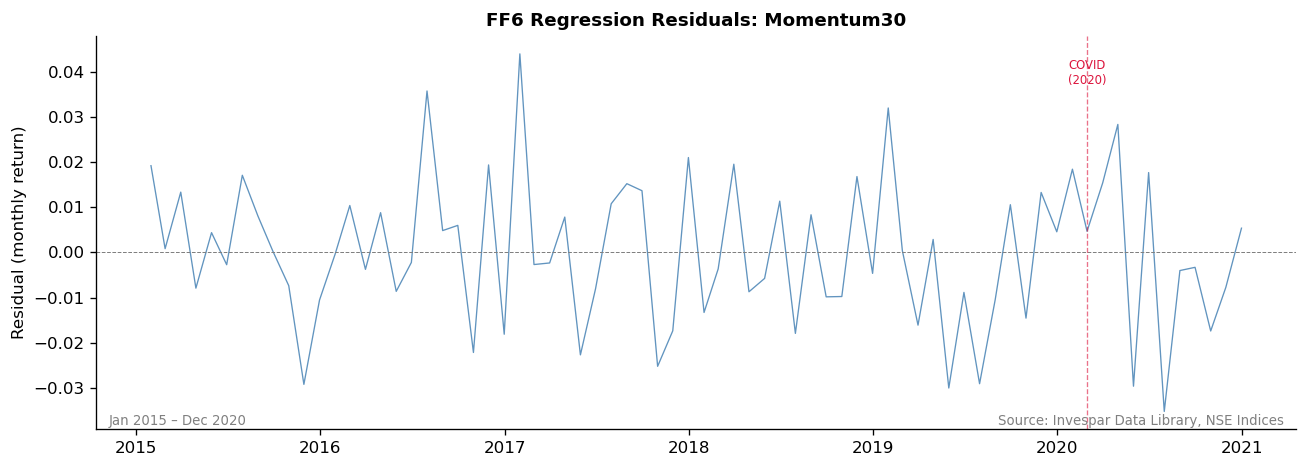

In [11]:
residuals = ff6_m.resid

fig, ax = plt.subplots(figsize=(11, 4), dpi=120)
ax.plot(residuals.index, residuals, color='steelblue', linewidth=0.8, alpha=0.85)
ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')

# Annotate crisis periods
for label, date_str in [('GFC\n(2008)', '2008-10-01'), ('COVID\n(2020)', '2020-03-01')]:
    d = pd.Timestamp(date_str)
    if residuals.index.min() <= d <= residuals.index.max():
        nearest = residuals.index[residuals.index.get_indexer([d], method='nearest')[0]]
        ax.axvline(nearest, color='crimson', linewidth=0.8, linestyle='--', alpha=0.6)
        ax.text(nearest, residuals.max() * 0.85, label, fontsize=7,
                color='crimson', ha='center')

ax.set_title('FF6 Regression Residuals: Momentum30', fontsize=11, fontweight='bold')
ax.set_ylabel('Residual (monthly return)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

period_str = f"{residuals.index.min().strftime('%b %Y')} – {residuals.index.max().strftime('%b %Y')}"
ax.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey')
ax.annotate('Source: Invespar Data Library, NSE Indices',
            xy=(0.99, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey', ha='right')

plt.tight_layout()
plt.show()

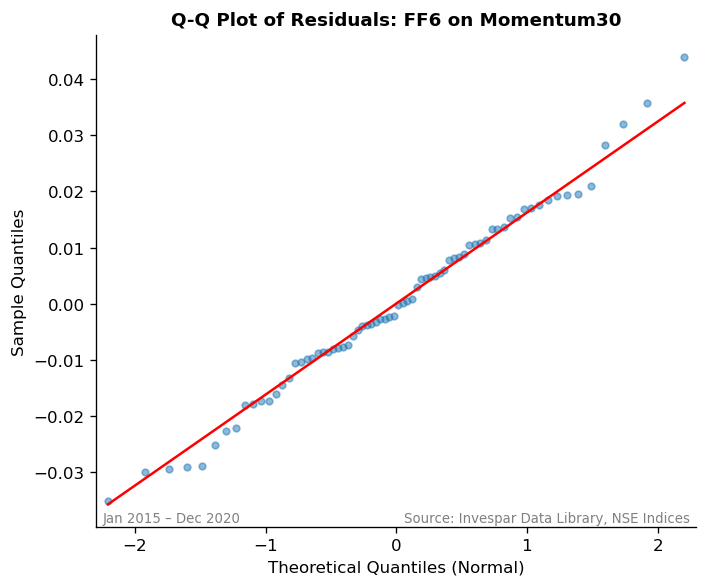

In [12]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)
sm.qqplot(residuals, line='s', ax=ax, alpha=0.5, markersize=4)
ax.set_title('Q-Q Plot of Residuals: FF6 on Momentum30', fontsize=11, fontweight='bold')
ax.set_xlabel('Theoretical Quantiles (Normal)', fontsize=10)
ax.set_ylabel('Sample Quantiles', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

period_str = f"{residuals.index.min().strftime('%b %Y')} – {residuals.index.max().strftime('%b %Y')}"
ax.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey')
ax.annotate('Source: Invespar Data Library, NSE Indices',
            xy=(0.99, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey', ha='right')

plt.tight_layout()
plt.show()

**Residual diagnostics: what the charts show**

The residual time series plot shows volatility clustering — residual magnitudes are larger during market stress periods. This is heteroscedasticity: the variance of the error term is not constant across time, violating one of OLS's core assumptions.

The Q-Q plot compares the empirical residual distribution against a normal distribution. If residuals were normally distributed, all points would lie on the 45° reference line. Departures at the extremes — the characteristic S-curve — indicate fat tails: extreme monthly returns occur more frequently than a normal distribution predicts.

These violations do not bias the OLS coefficient estimates (α and β remain unbiased under heteroscedasticity and autocorrelation). But they make the *standard errors* unreliable, which in turn makes t-statistics and p-values misleading. The fix applied throughout this series is **Newey-West (HAC) standard errors**, which correct for both heteroscedasticity and autocorrelation simultaneously. All regressions in the next notebook use HAC standard errors.

## 7  What We Established

| Topic | Key Point |
|-------|----------|
| Holdings vs returns | Return-based analysis is scalable and requires only a return stream |
| Risk-return tradeoff | Style indices cluster together; factors spread — same concepts, very different construction |
| APM framework | Linear decomposition: return = risk premia + alpha + noise |
| CAPM → FF6 | Each additional factor absorbs unexplained return; alpha shrinks when the right factor is included |
| Regression output | α = unexplained return, β = factor sensitivity, R² = fit, t-stat = significance |
| Practical hazards | Multicollinearity (use factors not indices), heteroscedasticity and autocorrelation (use HAC standard errors), fat tails (interpret p-values cautiously) |

---
**Next:** `03a_factor_models.ipynb` — applying the full six-factor model systematically across all Nifty indices, with rolling regressions and HAC standard errors.

## References

Markowitz, H. (1952). Portfolio Selection. *Journal of Finance*, 7(1), 77–91.

Sharpe, W.F. (1964). Capital Asset Prices: A Theory of Market Equilibrium under Conditions of Risk. *Journal of Finance*, 19(3), 425–442.

Fama, E.F. and French, K.R. (1993). Common Risk Factors in the Returns on Stocks and Bonds. *Journal of Financial Economics*, 33(1), 3–56.

Carhart, M.M. (1997). On Persistence in Mutual Fund Performance. *Journal of Finance*, 52(1), 57–82.

Fama, E.F. and French, K.R. (2015). A Five-Factor Asset Pricing Model. *Journal of Financial Economics*, 116(1), 1–22.

Harvey, C.R., Liu, Y., and Zhu, H. (2016). …and the Cross-Section of Expected Returns. *Review of Financial Studies*, 29(1), 5–68.

Raju, R. (2022). Four and Five-Factor Models in the Indian Equities Market. Available at SSRN: https://ssrn.com/abstract=4054146.

Invespar Indian Factor Library. Data source for all factor return series used in this notebook. https://invespar.com/research/